<a href="https://colab.research.google.com/github/brodyanderson/Project-Bank-Account-Fraud-/blob/main/Bank_Account_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bank Account Fraud Detection**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import random
import kagglehub
from scipy import stats

In [5]:
path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")

Using Colab cache for faster access to the 'bank-account-fraud-dataset-neurips-2022' dataset.


## **Load Saved Data from Drive (previously run)**

## **Exploratory Data Analysis**

In [7]:
print(os.listdir(path))
bank_df = pd.read_csv(f'{path}/Base.csv')

print("\nShape:", bank_df.shape)
print("\nData types:")
print(bank_df.dtypes)
print("\nMissing values:")
print(bank_df.isnull().sum())
print("\nClass distribution:")
print(bank_df['fraud_bool'].value_counts())

['Base.csv', 'Variant IV.csv', 'Variant V.csv', 'Variant I.csv', 'Variant III.csv', 'Variant II.csv']

Shape: (1000000, 32)

Data types:
fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
credit_risk_score                     int64
email_is_free                         int64
housing_status                       object
phone_home_valid           

In [8]:
bank_df.duplicated().sum()

np.int64(0)

In [9]:
# payment_type                         object
# employment_status                    object
# housing_status                       object
# source                               object
# device_os                            object

In [29]:
print((bank_df['prev_address_months_count'] == -1).sum())

712920


In [10]:
print(bank_df['fraud_bool'].sum() / len(bank_df))

0.011029


In [13]:
numeric_vars = bank_df.select_dtypes(include='number').columns.tolist()

summary_table = (
    bank_df[numeric_vars]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
    .rename(columns={'mean': 'Mean', 'std': 'SD', 'min': 'Min', '25%': 'Q1',
                     '50%': 'Median', '75%': 'Q3', 'max': 'Max'})
    [['Min', 'Q1', 'Median', 'Mean', 'Q3', 'Max', 'SD']]
    .round(2)
    .reset_index()
    .rename(columns={'index': 'Variable'})
)

summary_table.set_index('Variable')

,Min,Q1,Median,Mean,Q3,Max,SD
Variable,,,,,,,
fraud_bool,0.00,0.00,0.00,0.01,0.00,1.00,0.10
income,0.10,0.30,0.60,0.56,0.80,0.90,0.29
name_email_similarity,0.00,0.23,0.49,0.49,0.76,1.00,0.29
prev_address_months_count,-1.00,-1.00,-1.00,16.72,12.00,383.00,44.05
current_address_months_count,-1.00,19.00,52.00,86.59,130.00,428.00,88.41
customer_age,10.00,20.00,30.00,33.69,40.00,90.00,12.03
days_since_request,0.00,0.01,0.02,1.03,0.03,78.46,5.38
intended_balcon_amount,-15.53,-1.18,-0.83,8.66,4.98,112.96,20.24
zip_count_4w,1.00,894.00,1263.00,1572.69,1944.00,6700.00,1005.37


In [14]:
bank_df = bank_df.drop(columns=['device_fraud_count']) # this column is all zeros


In [30]:
for col in numeric_vars:
  print(col, (bank_df[col] == -1).sum())

fraud_bool 0
income 0
name_email_similarity 0
prev_address_months_count 712920
current_address_months_count 4254
customer_age 0
days_since_request 0
intended_balcon_amount 0
zip_count_4w 0
velocity_6h 0
velocity_24h 0
velocity_4w 0
bank_branch_count_8w 0
date_of_birth_distinct_emails_4w 0
credit_risk_score 488
email_is_free 0
phone_home_valid 0
phone_mobile_valid 0
bank_months_count 253635
has_other_cards 0
proposed_credit_limit 0
foreign_request 0
session_length_in_minutes 2015
keep_alive_session 0
device_distinct_emails_8w 359
month 0


In [ ]:
bank_df = bank_df.drop(columns=['prev_address_months_count', 'bank_months_count']) # too many -1 (NaN) values

In [38]:
bank_df = bank_df.drop(columns=['month'])

In [33]:
print((bank_df['fraud_bool'] == 1).sum())
print((bank_df['fraud_bool'] == 0).sum())

11029
988971


In [34]:
bank_df = bank_df[
    (bank_df['current_address_months_count'] >= 0) &
    (bank_df['session_length_in_minutes'] >= 0) &
    (bank_df['device_distinct_emails_8w'] >= 0)
]

In [35]:
print((bank_df['fraud_bool'] == 1).sum())
print((bank_df['fraud_bool'] == 0).sum())

10995
982612


In [37]:
for col in numeric_vars:
  print(col, (bank_df[col] == -1).sum())

fraud_bool 0
income 0
name_email_similarity 0
current_address_months_count 0
customer_age 0
days_since_request 0
intended_balcon_amount 0
zip_count_4w 0
velocity_6h 0
velocity_24h 0
velocity_4w 0
bank_branch_count_8w 0
date_of_birth_distinct_emails_4w 0
credit_risk_score 484
email_is_free 0
phone_home_valid 0
phone_mobile_valid 0
has_other_cards 0
proposed_credit_limit 0
foreign_request 0
session_length_in_minutes 0
keep_alive_session 0
device_distinct_emails_8w 0
month 0


In [43]:
bank_df['total_velocity'] = bank_df['velocity_6h'] + bank_df['velocity_24h'] + bank_df['velocity_4w']
bank_df['phone_consistency'] = bank_df['phone_home_valid'] + bank_df['phone_mobile_valid']
bank_df['credit_risk_ratio'] = bank_df['intended_balcon_amount'] / bank_df['proposed_credit_limit']
bank_df['credit_capacity'] = bank_df['income'] / bank_df['proposed_credit_limit']
bank_df['transaction_intensity'] = bank_df['total_velocity'] * bank_df['session_length_in_minutes']

In [44]:
numeric_vars = ['fraud_bool', 'income', 'name_email_similarity',
       'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w',
       'credit_risk_score', 'email_is_free',
       'phone_home_valid', 'phone_mobile_valid',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request',
       'session_length_in_minutes', 'keep_alive_session',
       'device_distinct_emails_8w', 'total_velocity', 'phone_consistency',
       'credit_risk_ratio', 'credit_capacity', 'transaction_intensity']

In [40]:
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

for col in cat_cols:
    print(f"\n{col}:")

    total_counts = bank_df[col].value_counts().sort_index()

    table = pd.DataFrame({
        'Category':   total_counts.index,
        'Count':      total_counts.values,
        'Proportion': (total_counts.values / total_counts.sum()).round(3)
    })

    print(table.to_string(index=False))


payment_type:
Category  Count  Proportion
      AA 257573       0.259
      AB 368115       0.370
      AC 249692       0.251
      AD 117938       0.119
      AE    289       0.000

employment_status:
Category  Count  Proportion
      CA 725305       0.730
      CB 137624       0.139
      CC  37506       0.038
      CD  26305       0.026
      CE  22579       0.023
      CF  43838       0.044
      CG    450       0.000

housing_status:
Category  Count  Proportion
      BA 169122       0.170
      BB 259562       0.261
      BC 368343       0.371
      BD  26021       0.026
      BE 168660       0.170
      BF   1648       0.002
      BG    251       0.000

source:
Category  Count  Proportion
INTERNET 988252       0.995
 TELEAPP   5355       0.005

device_os:
 Category  Count  Proportion
    linux 330831       0.333
macintosh  53487       0.054
    other 339809       0.342
  windows 262287       0.264
      x11   7193       0.007


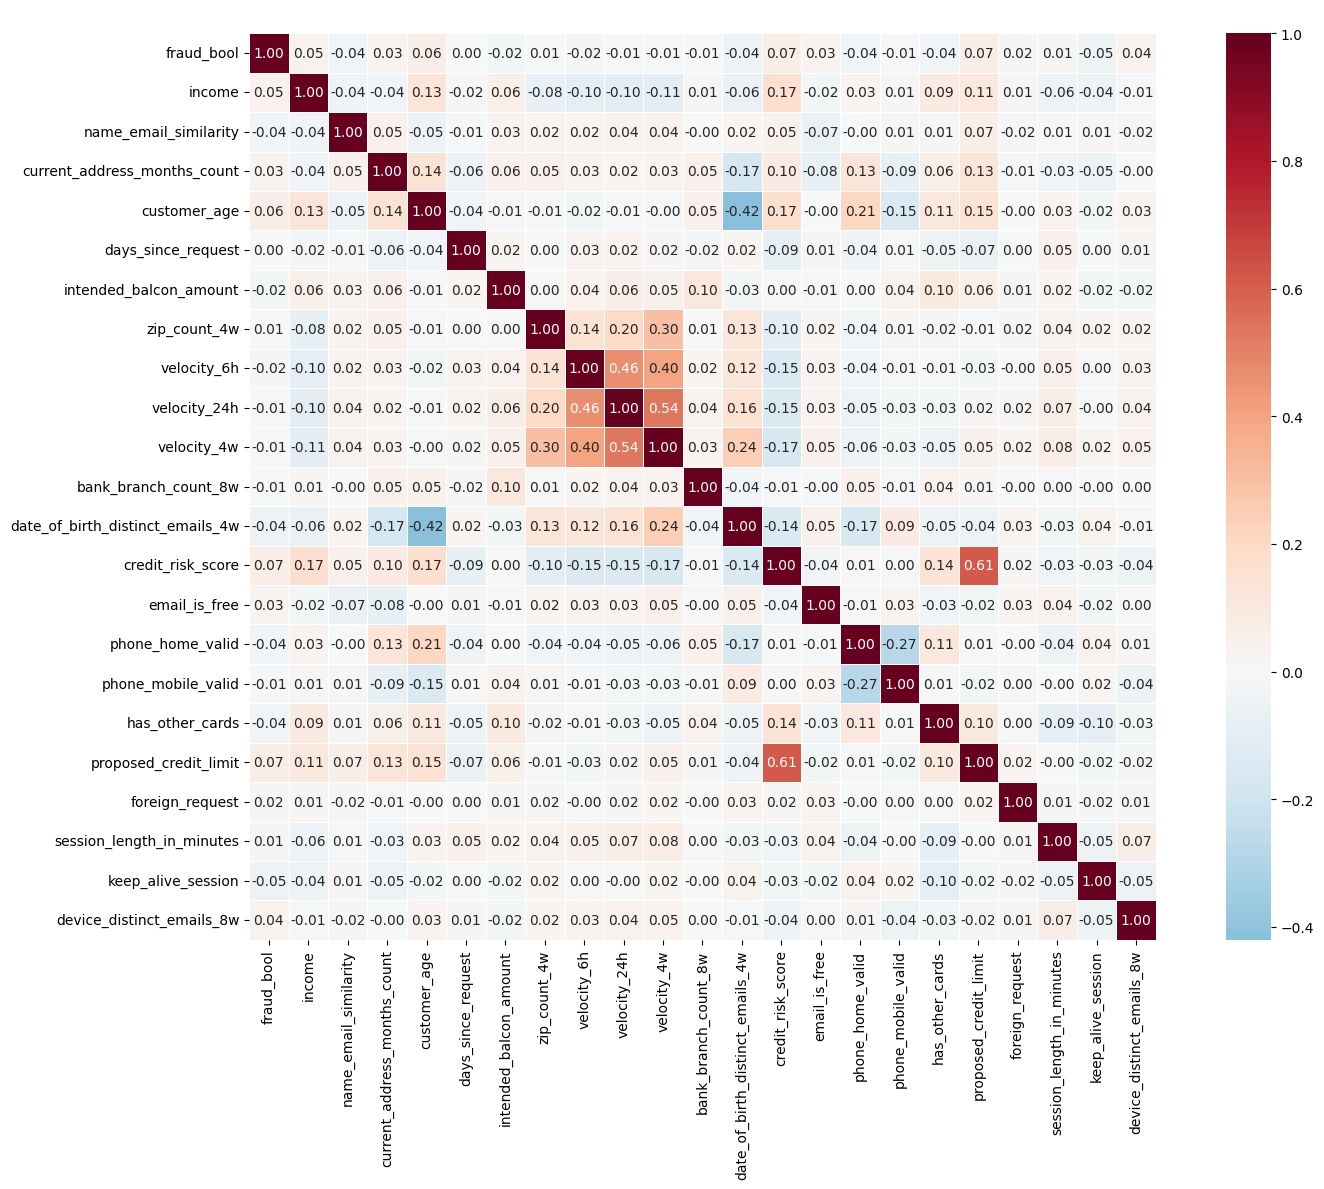

In [41]:
corr_matrix = bank_df[numeric_vars].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5)

plt.title(' ', fontsize=16) # Correlation Matrix
plt.tight_layout()
#plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

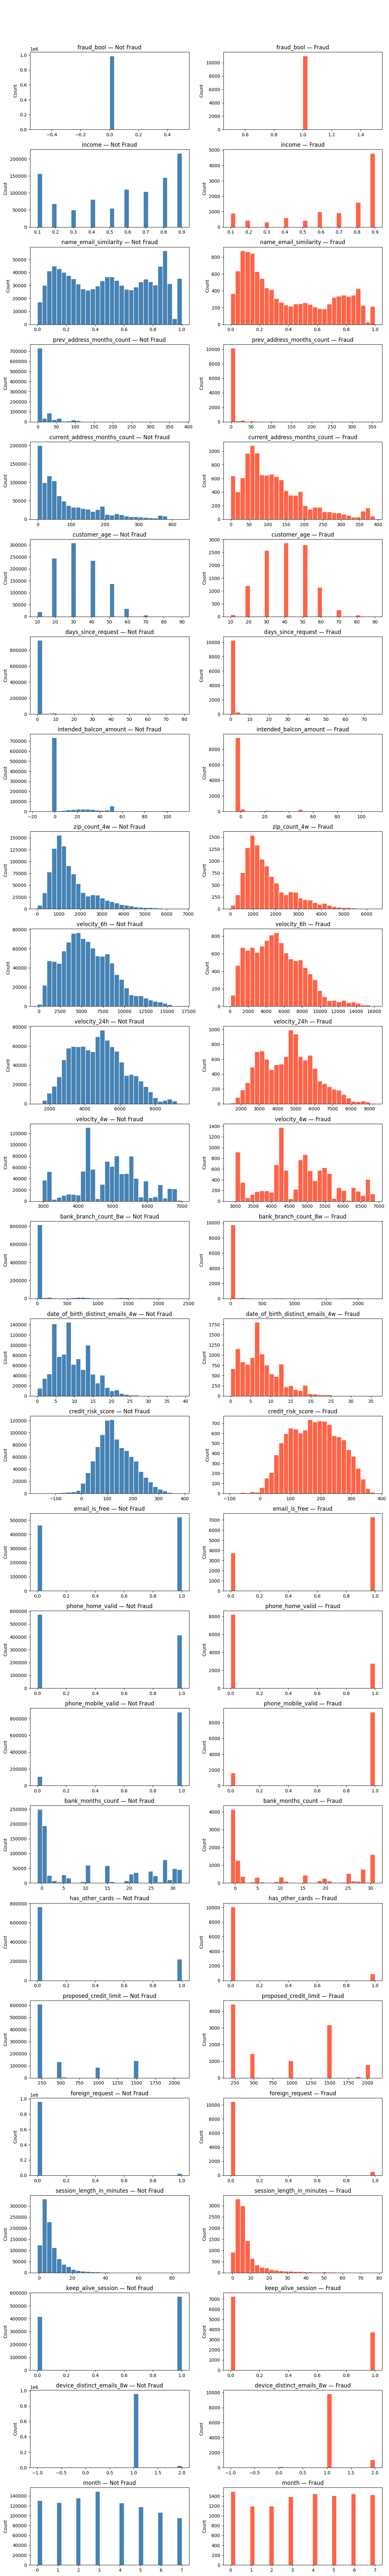

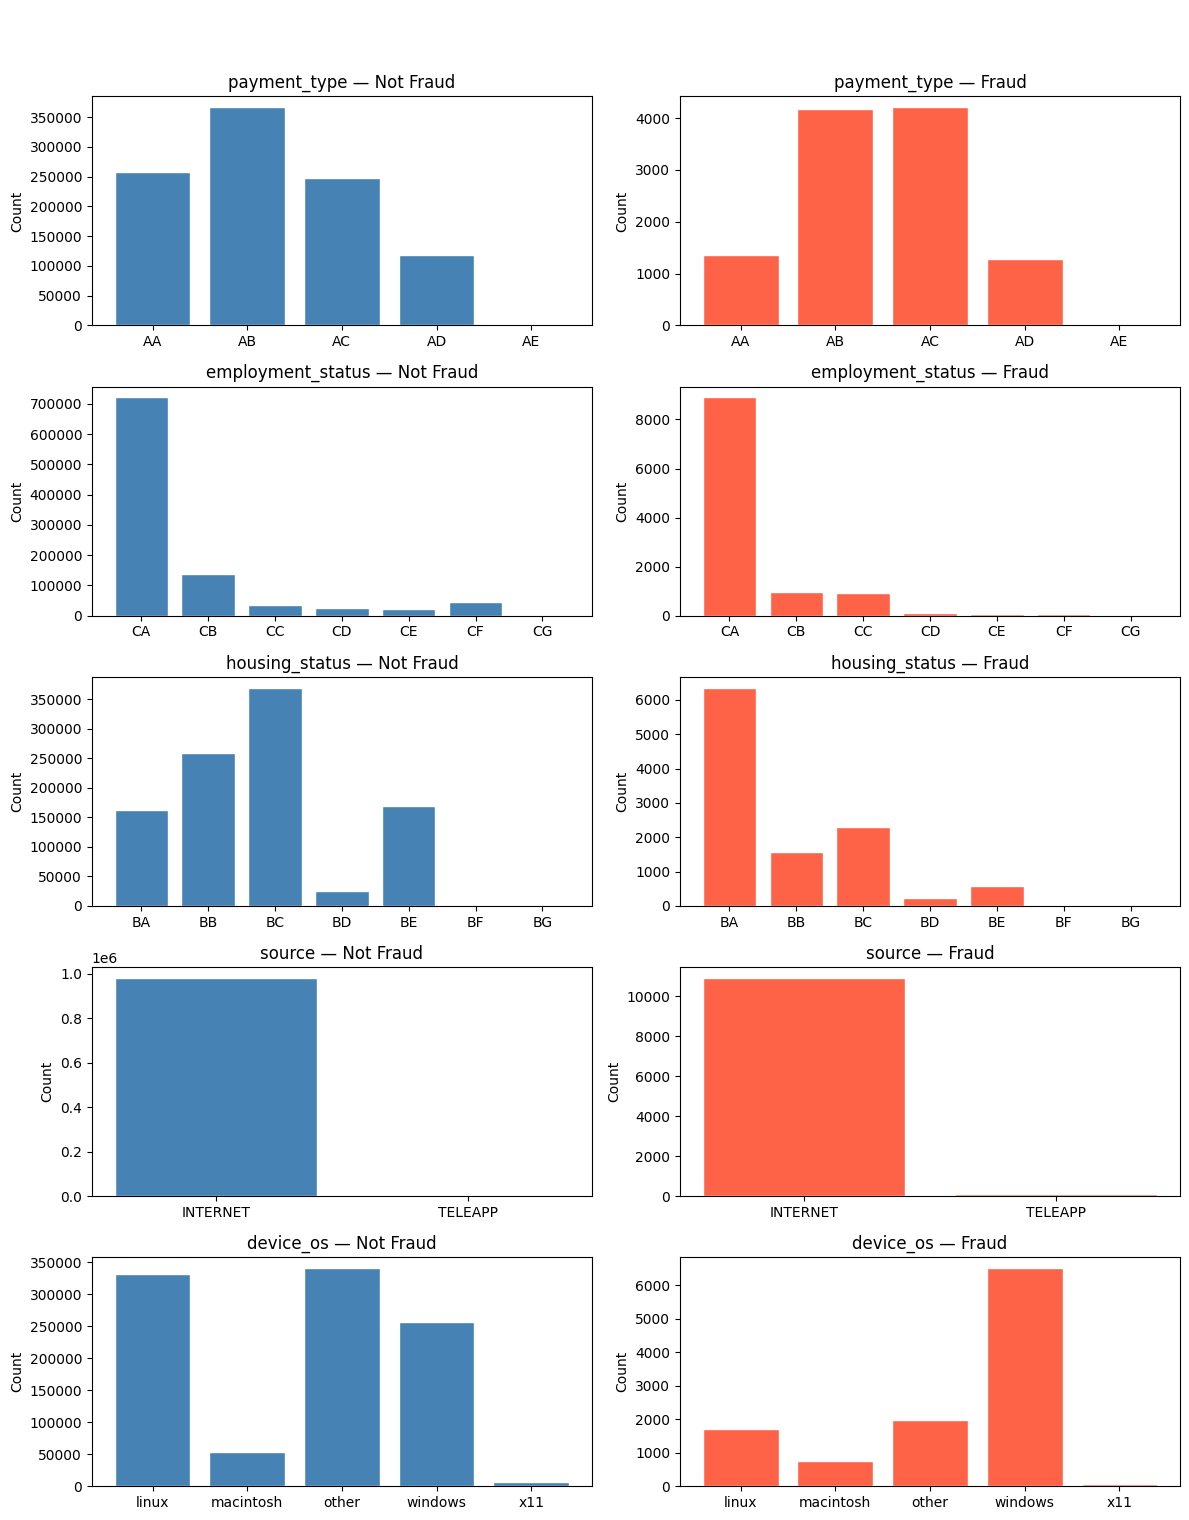

In [18]:
df_no_fraud = bank_df[bank_df['fraud_bool'] == 0]
df_fraud   = bank_df[bank_df['fraud_bool'] == 1]

# Numeric Variable Histograms
fig, axes = plt.subplots(len(numeric_vars), 2, figsize=(12, len(numeric_vars) * 3))

for i, col in enumerate(numeric_vars):
    axes[i, 0].hist(df_no_fraud[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Not Fraud')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].hist(df_fraud[col].dropna(), bins=30, color='tomato', edgecolor='white')
    axes[i, 1].set_title(f'{col} — Fraud')
    axes[i, 1].set_ylabel('Count')

plt.suptitle(' ', fontsize=14, y=1.01) # Numeric Variable Distributions by Fraud Status
plt.tight_layout()
#plt.savefig('continuous_distributions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Categorical Variable Bar Charts
fig, axes = plt.subplots(len(cat_cols), 2, figsize=(12, len(cat_cols) * 3))

for i, col in enumerate(cat_cols):
    no_inj_counts = df_no_fraud[col].value_counts().sort_index()
    inj_counts    = df_fraud[col].value_counts().sort_index()

    axes[i, 0].bar(no_inj_counts.index.astype(str), no_inj_counts.values, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Not Fraud')
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].bar(inj_counts.index.astype(str), inj_counts.values, color='tomato', edgecolor='white')
    axes[i, 1].set_title(f'{col} — Fraud')
    axes[i, 1].set_ylabel('Count')

plt.suptitle(' ', fontsize=14, y=1.01) # Categorical Variable Distributions by Fraud Status
plt.tight_layout()
#plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

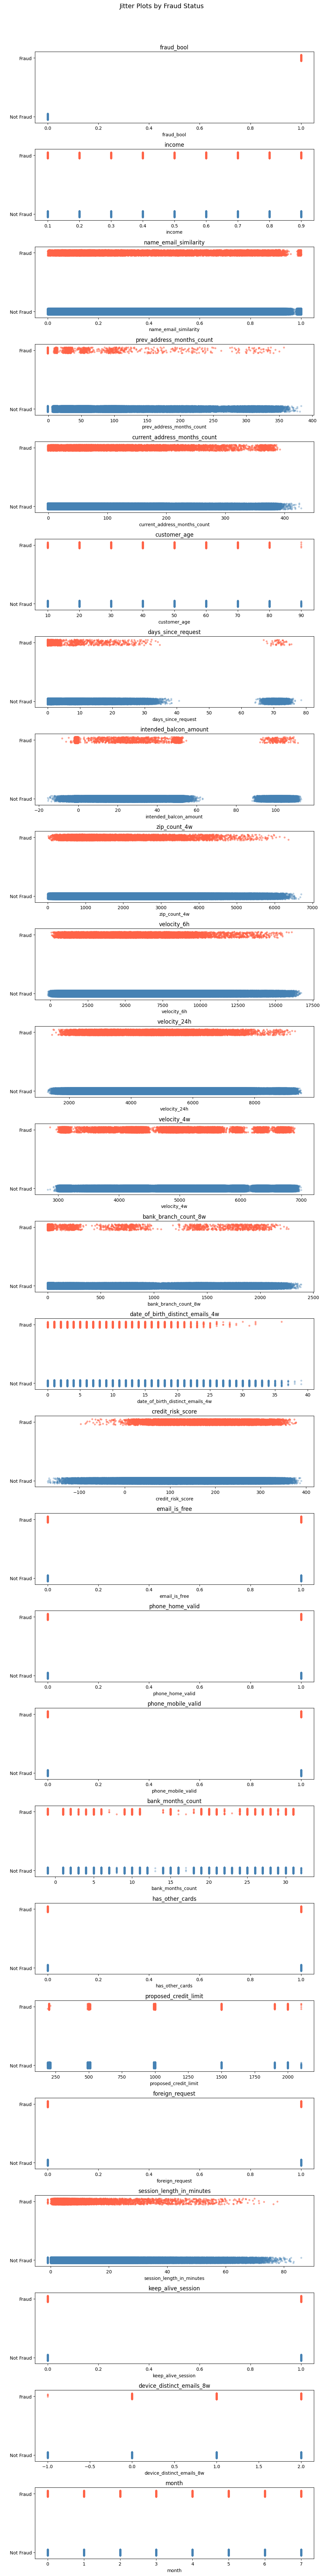

In [19]:
fig, axes = plt.subplots(len(numeric_vars), 1, figsize=(10, len(numeric_vars) * 3))

for i, col in enumerate(numeric_vars):
    axes[i].scatter(
        df_no_fraud[col],
        df_no_fraud['fraud_bool'] + np.random.uniform(-0.05, 0.05, len(df_no_fraud)),
        alpha=0.3, color='steelblue', s=10, label='No Fraud'
    )
    axes[i].scatter(
        df_fraud[col],
        df_fraud['fraud_bool'] + np.random.uniform(-0.05, 0.05, len(df_fraud)),
        alpha=0.5, color='tomato', s=10, label='Fraud'
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel(' ')
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['Not Fraud', 'Fraud'])
    axes[i].set_title(col)

plt.suptitle('Jitter Plots by Fraud Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## **Feature Creation**

## **Train / Test Split, Encode Categorical Variables & Scale**

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
print("Categorical columns:", cat_cols)

X = bank_df.drop(columns=['fraud_bool'])
y = bank_df['fraud_bool']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=865, stratify=y)

# Logistic Regression - Dummy Encoding (drop_first=True)
train_logistic = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
test_logistic  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# Make sure test has same columns as train
missing_cols = set(train_logistic.columns) - set(test_logistic.columns)
for col in missing_cols:
    test_logistic[col] = 0
test_logistic = test_logistic[train_logistic.columns]

# Random Forest - One Hot Encoding (drop_first=False)
train_ohe = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
test_ohe  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=False)

# Make sure test has same columns as train
missing_cols = set(train_ohe.columns) - set(test_ohe.columns)
for col in missing_cols:
    test_ohe[col] = 0
test_ohe = test_ohe[train_ohe.columns]

print("Logistic train shape:", train_logistic.shape)
print("Logistic test shape:", test_logistic.shape)
print("OHE train shape:", train_ohe.shape)
print("OHE test shape:", test_ohe.shape)

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
Logistic train shape: (800000, 46)
Logistic test shape: (200000, 46)
OHE train shape: (800000, 51)
OHE test shape: (200000, 51)
